# Microblogging · Neo4j

[Demo-Übersicht](README.md) · [Vorbereitung](../../README_technical_preparation.md) · [UAP-Aufgabe](../../tasks/03_neo4j/README.md)

Wer folgt wem, wer verfasst Beiträge und welche Verbindungen lassen sich verfolgen?
**Modellblick und Q3 bilden den Kern dieser Demonstration.** Q1, Q2, Q4 und Q5 bleiben ausführbare Vergleichsfragen und Vertiefung.

Wir verwenden denselben Bestand und dieselben Kennzahlendefinitionen wie in SQLite und MongoDB.

## 0. Verbindung und Eingabedaten

Kernel: **Python (rothstein-storage-workshop-2026)**.

### Vor der ersten Codezelle: den gewählten Neo4j-Dienst verwenden

**Wähle genau einen Betriebsweg. Eine neue Desktop-Instanz ist nur für Weg B nötig, wenn noch keine passende Instanz vorhanden ist.**

| Weg | Vor dem Notebook | Graphansicht nach dem Import |
| --- | --- | --- |
| **A: lokal mit Docker** | Neo4j-Desktop-Instanzen stoppen; den eingerichteten Neo4j-Container verwenden. | [Weboberfläche öffnen](http://localhost:7474/browser/); dort mit der unter **Neo4j-Ziel** angezeigten Adresse anmelden (Standard: `bolt://127.0.0.1:7687`). |
| **B: lokal ohne Docker** | Einen laufenden Neo4j-Kurscontainer zuerst stoppen; die Desktop-Kursinstanz starten. | Bei derselben Instanz **Open → Neo4j Browser** (1.x) bzw. **Connect → Query** (2.x) |
| **C: Codespaces** | Den automatischen Dienststart abwarten; den Host `neo4j` aus der Containerkonfiguration verwenden. | Über die weitergeleitete Codespaces-Adresse; keine lokale Desktop-Instanz starten. |

**Portkonflikt vermeiden:** Weg A und B belegen lokal standardmässig `7474` (Weboberfläche) und `7687` (Bolt). Betreibe dort nur einen Neo4j-Server. Beim Wechsel zu Weg B im bisherigen Repo-Ordner `docker compose stop neo4j` ausführen, solange noch die bisherige Compose-Konfiguration vorliegt. Andere Neo4j-Container gegebenenfalls in Docker Desktop stoppen. Docker darf für MongoDB weiterlaufen.

Die [Neo4j-Startanleitung für A, B und C](../../docs/setup/NEO4J_START.md) beschreibt Start, Verbindung, Graphansicht und den Wechsel zwischen den Wegen. **Nur für Weg B:** [Desktop einrichten](../../docs/setup/NEO4J_DESKTOP.md). Eine bestehende Kursinstanz weiterverwenden. Anzeigename: **rothstein-storage-workshop-2026**, Benutzer: `neo4j`, Standardpasswort: `Storage-Neo4j-2026`, Datenbank: `neo4j`.

Lokal verwenden die Notebooks bei den Standardwerten `127.0.0.1:7687`. Abweichende Zugangsdaten in einer vorhandenen `.env` anpassen; danach den Kernel neu starten. Codespaces setzt die internen Hosts und Ports automatisch. **Erst nach erfolgreichem Dienststart die Python-Codezellen ausführen.**

Die ursprünglichen `graph/`-CSVs bleiben als Referenz erhalten. Für den vollständigen Import verwenden wir die vorhandenen relationalen CSV-Eingaben: Dort sind Kommentar- und Like-IDs, Posttexte und Zeitpunkte eindeutig verfügbar. Das sind Eingabedateien; eine SQLite-Datenbank wird dafür nicht benötigt.


In [15]:
from pathlib import Path
import sys
import json
from datetime import datetime, timedelta, timezone
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pprint import pprint

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "scripts/neo4j_workshop.py").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Öffne das Notebook innerhalb des Repositories.")
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))
from neo4j_workshop import (prepare_graph, graph_scope, import_snapshot, graph_counts,
                           query_graph, write_pairings, draw_paths)
from storage_runtime import connection_summary
pd.set_option("display.max_colwidth", 90)
print("Neo4j-Ziel:", connection_summary()["Neo4j"])

DATASET = "microblogging"
SCOPE = graph_scope(DATASET)
graph = prepare_graph(DATASET)
print("Arbeitsbereich:", SCOPE)
print("Knoten:",len(graph["nodes"]),"Kanten:",len(graph["edges"]))
pprint(graph["nodes"][0])
pprint(next(e for e in graph["edges"] if e["type"]=="COMMENTED"))

Neo4j-Ziel: neo4j:7687
Arbeitsbereich: microblogging_demo
Knoten: 1065 Kanten: 5690
{'label': 'User',
 'node_id': 'user:1',
 'properties': {'created_at': datetime.date(2024, 11, 6),
                'user_id': 1,
                'username': 'user_qahftr'}}
{'edge_id': 'comments:1',
 'properties': {'at': datetime.datetime(2025, 8, 25, 16, 0, tzinfo=datetime.timezone.utc),
                'comment_id': 1,
                'text': 'Like mongodb cloud trend coffee data ml sqlite follow '
                        'cloud ml graph sql nlp.'},
 'source': 'user:104',
 'target': 'post:1',
 'type': 'COMMENTED'}


### Notebook und Neo4j Browser verwenden denselben Graphen

1. Führe im Notebook die Codezellen von **0 und 1** bis **IMPORT OK** aus. Damit sind die Daten vorbereitet.
2. Öffne bei **Weg A** den [Neo4j Browser](http://localhost:7474/browser/). Wähle im Anmeldefenster **Protocol: `bolt://`** und trage bei **Connection URL** den Host und Port aus der Notebook-Ausgabe **Neo4j-Ziel** ein. Standard: `127.0.0.1:7687`; bei geändertem Port gilt Dein angezeigter Wert. Benutzer: **neo4j**, Passwort: **Storage-Neo4j-2026** beziehungsweise Dein eigenes, Datenbank: **neo4j**. Bei geändertem HTTP-Port passe auch die Webadresse an.
3. Bei **Weg B** öffnest Du den Browser beziehungsweise **Query** bei der laufenden Instanz in Neo4j Desktop. Bei **Weg C** öffnest Du im Codespace unter **Ports** den Port **8080** und folgst dort dem Link zum Neo4j Browser; siehe [Codespaces-Anleitung](../../docs/setup/NEO4J_START.md#weg-c-codespaces).
4. Führe die weiteren Notebook-Zellen der Reihe nach aus. Kopiere jeweils den kurzen **Cypher-Block** unter «Im Neo4j Browser» ins Eingabefeld des Neo4j Browsers, klicke auf **▶** und vergleiche das Ergebnis mit der Notebook-Ausgabe darüber.

**Webadresse und Datenbankadresse haben unterschiedliche Aufgaben:** Die `http://…`-Adresse öffnet die Oberfläche im Webbrowser. Die `bolt://…`-Adresse gehört in die Verbindungseinstellungen dieser Oberfläche.

Die Browser-Abfragen enthalten alle benötigten Werte. `scope: 'microblogging_demo'` wählt den gemeinsamen Demo-Bestand. **Der Datenimport erfolgt einmal im Notebook; eine Parameterliste musst Du nicht übertragen.** Die Browser-Blöcke lesen die bereits gespeicherten Daten.

**Table** zeigt Werte und Kennzahlen. Eine Abfrage, die einen Pfad `p` zurückgibt, bietet zusätzlich **Graph** für die interaktive Darstellung. Ein Tabellenresultat wie `count(...)` erzeugt allein keine Graphansicht.

## 1. Das Modell und die Identität eines Kommentars

| Ausgang | Beziehung | Ziel | Eigenschaften |
| --- | --- | --- | --- |
| Nutzer | `FOLLOWS` | Nutzer | Beginn der Follow-Beziehung |
| Nutzer | `AUTHORED` | Post | Erstellungszeitpunkt |
| Nutzer | `LIKES` | Post | Like-ID, Zeitpunkt |
| Nutzer | `COMMENTED` | Post | Kommentar-ID, Zeitpunkt, Text |

Im Code heissen die Knotenlabels `StorageUser` und `StoragePost`. Der Kurspräfix hält sie von anderen Beispielen in derselben Datenbank getrennt. Das gemeinsame Label `StorageNode` trägt `scope` und `node_id`.

**Ein Kommentar ist eine einzelne Beziehung mit eigener ID.** Zwei Kommentare derselben Person zum selben Post bleiben zwei Beziehungen. Nutzer 6 kommentiert Post 284 zweimal. Ein `MERGE (u)-[:COMMENTED]->(p)` ohne Kommentaridentität würde diese beiden Ereignisse zusammenfassen.

Die Datenbank erzwingt die eindeutige Kombination `(scope, node_id)`. Der Import prüft zusätzlich Endpunkte und eindeutige Kanten-IDs. Siehe [Schema und Modellentscheidungen](../../schemas/neo4j/README.md).

In [16]:
schema_query = """CREATE CONSTRAINT storage_node_scope_id IF NOT EXISTS
FOR (n:StorageNode) REQUIRE (n.scope, n.node_id) IS UNIQUE"""
print(schema_query)
first = import_snapshot(DATASET,SCOPE)
second = import_snapshot(DATASET,SCOPE)
assert first == second
assert first["nodes"]==1065 and first["types"]=={
    "FOLLOWS":3047,"AUTHORED":865,"LIKES":1266,"COMMENTED":512}
pprint(first)
print("IMPORT OK")

CREATE CONSTRAINT storage_node_scope_id IF NOT EXISTS
FOR (n:StorageNode) REQUIRE (n.scope, n.node_id) IS UNIQUE
{'edges': 5690,
 'labels': {'Post': 865, 'User': 200},
 'nodes': 1065,
 'types': {'AUTHORED': 865, 'COMMENTED': 512, 'FOLLOWS': 3047, 'LIKES': 1266}}
IMPORT OK


### Im Neo4j Browser · Den importierten Bestand prüfen

Führe die beiden Abfragen einzeln aus. Die Werte entsprechen der Notebook-Ausgabe darüber.

```cypher
MATCH (n:StorageNode {scope: 'microblogging_demo'})
RETURN count(n) AS Knoten;
```

**Vergleich:** `1065` Knoten: `200` Nutzer und `865` Posts.

```cypher
MATCH (:StorageNode {scope: 'microblogging_demo'})-[r]->()
RETURN type(r) AS Beziehungstyp, count(r) AS Anzahl
ORDER BY Beziehungstyp;
```

**Vergleich:** `865` AUTHORED, `512` COMMENTED, `3047` FOLLOWS und `1266` LIKES; zusammen `5690` Beziehungen.

Der erneute Import ersetzt ausschliesslich **diesen Demo-Bereich**, in einer Datentransaktion. Ein Fehler beim Datenimport erhält den zuvor bestätigten Bestand. Die separate Schemaanlage geht dieser Transaktion voraus.

UAP-Aufgabe und Musterlösung liegen in anderen Bereichen. Ein erneuter Import derselben Demo setzt eigene Änderungen innerhalb dieser Demo zurück; er setzt keine ganze Datenbank zurück.

### Im Neo4j Browser · Wem folgt Nutzer 1?

```cypher
MATCH p = (:StorageUser {scope: 'microblogging_demo', user_id: 1})
          -[:FOLLOWS]->(:StorageUser)
RETURN p LIMIT 25;
```

Wähle **Graph**. Du siehst bis zu 25 direkte Follow-Beziehungen von Nutzer 1. Klicke auf einen Knoten oder eine Beziehung, um die Eigenschaften anzusehen. Nach Änderungen im Notebook genügt es, die Abfrage erneut auszuführen.

**Notebook und Browser müssen mit derselben Instanz verbunden sein.** Eine lokale Datenbank und eine Datenbank im Codespace haben getrennte Bestände.


In [17]:
repeated_comments = query_graph(SCOPE,"""
MATCH (:StorageUser {scope:$scope,user_id:6})-[r:COMMENTED {scope:$scope}]->
      (:StoragePost {scope:$scope,post_id:284})
RETURN r.comment_id AS comment_id, toString(r.at) AS at, r.text AS text
ORDER BY comment_id
""")
display(pd.DataFrame(repeated_comments))
assert len(repeated_comments)==2

,comment_id,at,text
0,193,2025-08-17T09:00:00Z,Mongodb music mongodb ml follow coffee social neo4j cloud.
1,194,2025-08-18T00:00:00Z,Neo4j neo4j coffee sqlite python.


### Im Neo4j Browser · Dieselben zwei Kommentare

```cypher
MATCH (:StorageUser {scope: 'microblogging_demo', user_id: 6})
      -[r:COMMENTED]->(:StoragePost {post_id: 284})
RETURN r.comment_id AS comment_id, toString(r.at) AS at, r.text AS text
ORDER BY comment_id;
```

**Vergleich:** dieselben zwei Tabellenzeilen wie im Notebook, mit den Kommentar-IDs `193` und `194`. Gleiche Endpunkte bedeuten hier nicht denselben Kommentar.

## Q3 · Beziehungen und gerichteter Pfad — Kerndemo

Ein eingehendes `FOLLOWS` zählt einen Follower, ein ausgehendes ein Following.
`OPTIONAL MATCH` erhält auch Nutzer ohne Beziehungen. `count(f)` zählt nur gefundene Beziehungen; `count(*)` würde auch eine erhaltene Zeile ohne Treffer mitzählen.

In [18]:
query_degrees = """
MATCH (u:StorageUser {scope:$scope})
OPTIONAL MATCH (:StorageUser {scope:$scope})-[f:FOLLOWS {scope:$scope}]->(u)
WITH u, count(f) AS followers
OPTIONAL MATCH (u)-[g:FOLLOWS {scope:$scope}]->(:StorageUser {scope:$scope})
RETURN u.user_id AS user_id, u.username AS username, followers, count(g) AS following
ORDER BY followers DESC, user_id
"""
query_path = """
MATCH (a:StorageUser {scope:$scope, user_id:$src}),
      (b:StorageUser {scope:$scope, user_id:$dst})
MATCH p = allShortestPaths((a)-[:FOLLOWS*1..6]->(b))
WHERE all(n IN nodes(p) WHERE n.scope = $scope)
  AND all(r IN relationships(p) WHERE r.scope = $scope)
RETURN length(p) AS hops, [n IN nodes(p) | n.user_id] AS user_ids
ORDER BY user_ids
LIMIT 1
"""

,user_id,username,followers,following
0,80,user_mgjpzs,27,23
1,90,user_gkogms,25,23
2,98,user_cbmprd,25,23
3,141,user_ticzdz,25,5
4,154,user_oucwdj,24,25
5,41,user_nroycw,22,22
6,71,user_kfkxps,22,22
7,91,user_ucfrhp,22,9
8,108,user_afrwpa,22,22
9,10,user_rfitbv,21,22


[{'hops': 2, 'user_ids': [1, 2, 3]}]


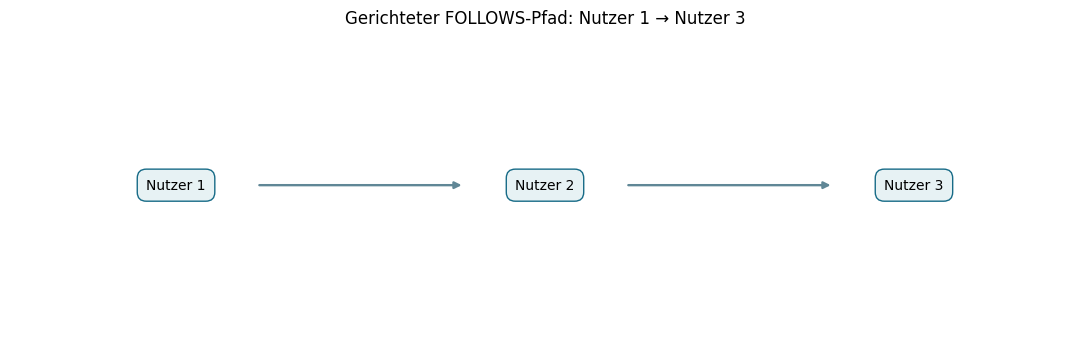

In [19]:
degrees = pd.DataFrame(query_graph(SCOPE,query_degrees))
path_rows = query_graph(SCOPE,query_path,src=1,dst=3)
display(degrees.head(10))
pprint(path_rows)
assert degrees["followers"].sum()==degrees["following"].sum()==3047
assert path_rows==[{"hops":2,"user_ids":[1,2,3]}]
_ = draw_paths([[f"Nutzer {uid}" for uid in p["user_ids"]] for p in path_rows],
           "Gerichteter FOLLOWS-Pfad: Nutzer 1 → Nutzer 3")

### Im Neo4j Browser · Follower und Following

```cypher
MATCH (u:StorageUser {scope: 'microblogging_demo'})
OPTIONAL MATCH (:StorageUser)-[f:FOLLOWS]->(u)
WITH u, count(f) AS followers
OPTIONAL MATCH (u)-[g:FOLLOWS]->(:StorageUser)
RETURN u.user_id AS user_id, u.username AS username, followers, count(g) AS following
ORDER BY followers DESC, user_id
LIMIT 10;
```

**Vergleich:** dieselben zehn Zeilen wie in `degrees.head(10)`. Nutzer `80` steht mit `27` Followern und `23` Followings an erster Stelle. Ohne `LIMIT 10` erhältst Du alle `200` Nutzer.

### Im Neo4j Browser · Derselbe gerichtete Pfad als Tabelle und Graph

```cypher
MATCH (a:StorageUser {scope: 'microblogging_demo', user_id: 1}),
      (b:StorageUser {scope: 'microblogging_demo', user_id: 3})
MATCH p = allShortestPaths((a)-[:FOLLOWS*1..6]->(b))
RETURN length(p) AS hops, [n IN nodes(p) | n.user_id] AS user_ids, p
ORDER BY user_ids
LIMIT 1;
```

**Vergleich:** In **Table** stehen `hops = 2` und `user_ids = [1, 2, 3]`, wie im Notebook. Die zusätzliche Spalte `p` enthält den Pfad: Wähle **Graph**, um dieselben drei Nutzer und die beiden gerichteten Beziehungen interaktiv anzusehen.

Bei mehreren kürzesten Pfaden wählt `ORDER BY user_ids` mit `LIMIT 1` dieselbe sortierte Nutzerfolge wie das Notebook.

Das Beispiel ist fest gewählt. Bei mehreren gleich kurzen Pfaden entscheidet die sortierte Folge der Nutzer-IDs. Der Pfad bedeutet: Nutzer 1 folgt Nutzer 2, und Nutzer 2 folgt Nutzer 3. Daraus folgt weder ein direktes Follow 1 → 3 noch eine gegenseitige Beziehung.

Die Suche ist auf sechs Schritte begrenzt. Kein Treffer würde deshalb nur «kein gerichteter Pfad innerhalb dieser Grenze» bedeuten. Ein kleiner Lehrgraph ist kein Leistungsbenchmark.

## Q1 · Aktivität pro Person — Vertiefung

Aktivität = verfasste Posts + verfasste Kommentare + gegebene Likes, jeweils im gesamten Bestand.
Jede optionale Beziehung wird **vor dem nächsten Match aggregiert**. Dadurch entstehen keine mehrfach gezählten Kombinationen von Posts, Kommentaren und Likes.

In [20]:
query_q1 = """
MATCH (u:StorageUser {scope:$scope})
OPTIONAL MATCH (u)-[a:AUTHORED {scope:$scope}]->(:StoragePost {scope:$scope})
WITH u, count(a) AS posts_count
OPTIONAL MATCH (u)-[c:COMMENTED {scope:$scope}]->(:StoragePost {scope:$scope})
WITH u, posts_count, count(c) AS comments_made
OPTIONAL MATCH (u)-[l:LIKES {scope:$scope}]->(:StoragePost {scope:$scope})
WITH u, posts_count, comments_made, count(l) AS likes_made
RETURN u.user_id AS user_id, u.username AS username,
       posts_count, comments_made, likes_made,
       posts_count + comments_made + likes_made AS engagement_score
ORDER BY engagement_score DESC, user_id
"""

,user_id,username,posts_count,comments_made,likes_made,engagement_score
0,94,user_ethptp,10,4,12,26
1,107,user_nmcbli,10,5,11,26
2,35,user_eycepr,5,6,14,25
3,11,user_kbxosf,8,4,12,24
4,43,user_rwngxb,9,3,11,23
5,104,user_yuqryl,7,7,9,23
6,156,user_muncny,10,6,7,23
7,15,user_kpmgoy,12,2,8,22
8,138,user_qxqilp,4,6,12,22
9,198,user_aitdje,9,3,10,22


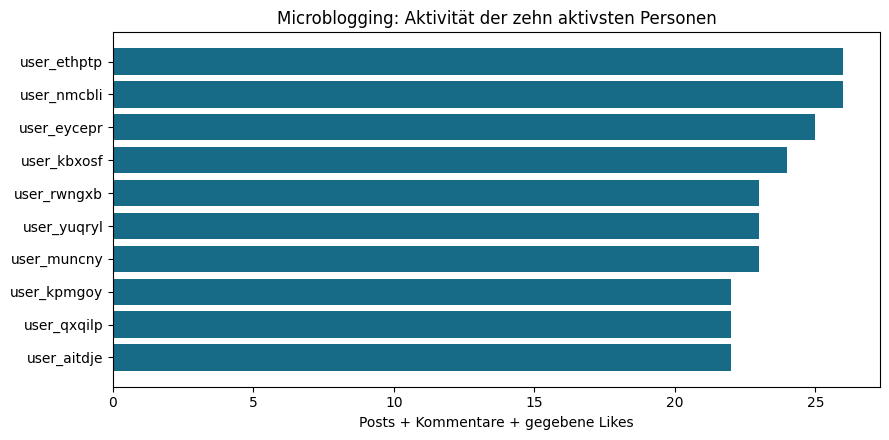

In [21]:
engagement = pd.DataFrame(query_graph(SCOPE,query_q1))
display(engagement.head(10))
assert len(engagement)==200
assert engagement[["posts_count","comments_made","likes_made"]].sum().tolist()==[865,512,1266]
assert engagement.iloc[:3]["user_id"].tolist()==[94,107,35]
assert engagement.iloc[:3]["engagement_score"].tolist()==[26,26,25]
top = engagement.head(10).iloc[::-1]
fig,ax = plt.subplots(figsize=(9,4.5))
ax.barh(top["username"],top["engagement_score"],color="#176B87")
ax.set(title="Microblogging: Aktivität der zehn aktivsten Personen",xlabel="Posts + Kommentare + gegebene Likes")
fig.tight_layout();plt.show()

### Im Neo4j Browser · Dieselben zehn aktivsten Personen

```cypher
MATCH (u:StorageUser {scope: 'microblogging_demo'})
OPTIONAL MATCH (u)-[a:AUTHORED]->(:StoragePost)
WITH u, count(a) AS posts_count
OPTIONAL MATCH (u)-[c:COMMENTED]->(:StoragePost)
WITH u, posts_count, count(c) AS comments_made
OPTIONAL MATCH (u)-[l:LIKES]->(:StoragePost)
WITH u, posts_count, comments_made, count(l) AS likes_made
RETURN u.user_id AS user_id, u.username AS username, posts_count, comments_made,
       likes_made, posts_count + comments_made + likes_made AS engagement_score
ORDER BY engagement_score DESC, user_id
LIMIT 10;
```

**Vergleich:** dieselben Zeilen und Kennzahlen wie in `engagement.head(10)`. Die ersten drei Nutzer sind `94`, `107` und `35`, mit den Werten `26`, `26` und `25`. Ohne `LIMIT 10` erhältst Du alle Nutzer.

## Q2 · Beliebtheit pro Post — Vertiefung

Gezählt werden empfangene Likes. Posts ohne Likes bleiben im Ergebnis. Die Tabelle enthält alle Posts; angezeigt wird nur ein Ausschnitt.

In [22]:
query_q2 = """
MATCH (a:StorageUser {scope:$scope})-[:AUTHORED {scope:$scope}]->(p:StoragePost {scope:$scope})
OPTIONAL MATCH (:StorageUser {scope:$scope})-[l:LIKES {scope:$scope}]->(p)
RETURN p.post_id AS post_id, a.username AS author,
       toString(p.created_at) AS created_at, count(l) AS like_count
ORDER BY like_count DESC, post_id
"""

In [23]:
popular_posts = pd.DataFrame(query_graph(SCOPE,query_q2))
display(popular_posts.head(10))
assert len(popular_posts)==865 and popular_posts["like_count"].sum()==1266
print("Posts ohne Likes:",int((popular_posts["like_count"]==0).sum()))

,post_id,author,created_at,like_count
0,136,user_ywemfk,2025-08-16T00:00:00Z,4
1,138,user_ywemfk,2025-08-26T00:00:00Z,4
2,184,user_nroycw,2025-08-13T00:00:00Z,4
3,291,user_djdfki,2025-08-26T00:00:00Z,4
4,292,user_djdfki,2025-09-05T00:00:00Z,4
5,293,user_djdfki,2025-08-26T00:00:00Z,4
6,336,user_zjquqt,2025-08-31T00:00:00Z,4
7,381,user_iwshay,2025-08-23T00:00:00Z,4
8,384,user_gkogms,2025-08-15T00:00:00Z,4
9,386,user_ucfrhp,2025-09-10T00:00:00Z,4


Posts ohne Likes: 228


### Im Neo4j Browser · Dieselben zehn beliebtesten Posts

```cypher
MATCH (a:StorageUser {scope: 'microblogging_demo'})-[:AUTHORED]->(p:StoragePost)
OPTIONAL MATCH (:StorageUser)-[l:LIKES]->(p)
RETURN p.post_id AS post_id, a.username AS author,
       toString(p.created_at) AS created_at, count(l) AS like_count
ORDER BY like_count DESC, post_id
LIMIT 10;
```

**Vergleich:** dieselben zehn Zeilen wie in `popular_posts.head(10)`. Die ersten Post-IDs sind `136`, `138` und `184`, mit jeweils `4` Likes.

Die Anzahl der Posts ohne Likes kannst Du separat vergleichen:

```cypher
MATCH (p:StoragePost {scope: 'microblogging_demo'})
WHERE NOT EXISTS { MATCH (:StorageUser)-[:LIKES]->(p) }
RETURN count(p) AS Posts_ohne_Likes;
```

**Vergleich:** `228`, wie in der Notebook-Ausgabe darüber.

## Q4 · Posts pro Kalendertag — Vertiefung

Neo4j zählt Posts pro Tag. **pandas ergänzt anschliessend fehlende Kalendertage und berechnet den gleitenden Durchschnitt** über bis zu sieben Tage. Die ursprünglich zeitzonenlosen synthetischen Daten verwenden dieselbe ausdrücklich gesetzte UTC-Konvention wie die MongoDB-Demo.

In [24]:
query_daily = """
MATCH (p:StoragePost {scope:$scope})
RETURN toString(date(p.created_at)) AS day, count(p) AS posts
ORDER BY day
"""

def complete_calendar(records):
    daily = pd.DataFrame(records)
    daily["day"] = pd.to_datetime(daily["day"], utc=True)
    daily = daily.set_index("day").sort_index()
    days = pd.date_range(daily.index.min(),daily.index.max(),freq="D")
    result = daily.reindex(days,fill_value=0).rename_axis("day").reset_index()
    result["rolling_7d"] = result["posts"].rolling(7,min_periods=1).mean()
    return result

,day,posts,rolling_7d
0,2025-08-12 00:00:00+00:00,22,22.000000
1,2025-08-13 00:00:00+00:00,24,23.000000
2,2025-08-14 00:00:00+00:00,31,25.666667
3,2025-08-15 00:00:00+00:00,39,29.000000
4,2025-08-16 00:00:00+00:00,31,29.400000
5,2025-08-17 00:00:00+00:00,28,29.166667
6,2025-08-18 00:00:00+00:00,38,30.428571
7,2025-08-19 00:00:00+00:00,23,30.571429


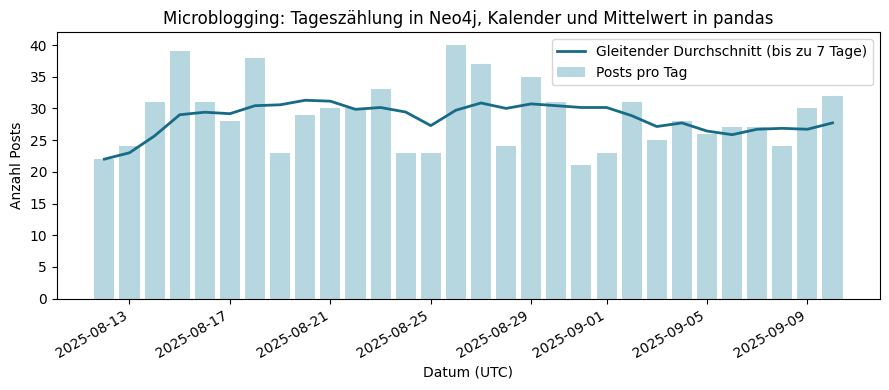

In [25]:
trend = complete_calendar(query_graph(SCOPE,query_daily))
display(trend.head(8))
assert len(trend)==30 and trend["posts"].sum()==865
fig,ax = plt.subplots(figsize=(9,4))
ax.bar(trend["day"],trend["posts"],color="#B6D7DF",label="Posts pro Tag")
ax.plot(trend["day"],trend["rolling_7d"],color="#176B87",lw=2,label="Gleitender Durchschnitt (bis zu 7 Tage)")
ax.set(title="Microblogging: Tageszählung in Neo4j, Kalender und Mittelwert in pandas",xlabel="Datum (UTC)",ylabel="Anzahl Posts")
ax.legend();fig.autofmt_xdate();fig.tight_layout();plt.show()

### Im Neo4j Browser · Dieselben Tageszählungen

```cypher
MATCH (p:StoragePost {scope: 'microblogging_demo'})
RETURN toString(date(p.created_at)) AS day, count(p) AS posts
ORDER BY day;
```

**Vergleich:** Vergleiche `day` und `posts` mit der Notebook-Tabelle. Die ersten drei Tageswerte sind `22`, `24` und `31`; im vorliegenden Bestand gibt es `30` Tage mit zusammen `865` Posts.

`rolling_7d` entsteht anschliessend in pandas und ist daher keine Ergebnisspalte dieser Cypher-Abfrage. Auch das Ergänzen fehlender Kalendertage geschieht in pandas; im vorliegenden Bestand hat jeder der 30 Tage Posts.

## Q5 · Feed mit festem Bezug zum Bestand — Vertiefung

Nutzer 1; Zeitfenster **[8. September 2025, 11. September 2025)**. Nur Follow-Beziehungen, die spätestens zu Fensterbeginn bestanden, zählen. Eine Unfollow-Historie ist nicht vorhanden.

Wir verwenden das Ende der gelieferten Datenperiode statt des heutigen Datums. Alle drei bislang ausgearbeiteten Modelle sollen denselben Feed liefern.

In [26]:
query_feed = """
MATCH (:StorageUser {scope:$scope, user_id:$viewer})-[f:FOLLOWS {scope:$scope}]->
      (a:StorageUser {scope:$scope})-[:AUTHORED {scope:$scope}]->(p:StoragePost {scope:$scope})
WHERE f.since <= $follow_cutoff AND p.created_at >= $since AND p.created_at < $until
WITH DISTINCT a, p
OPTIONAL MATCH (:StorageUser {scope:$scope})-[l:LIKES {scope:$scope}]->(p)
RETURN p.post_id AS post_id, a.username AS author, toString(p.created_at) AS created_at,
       count(l) AS like_count, substring(p.text,0,100) AS preview
ORDER BY created_at DESC, post_id
LIMIT 50
"""
last_day = max(n["properties"]["created_at"] for n in graph["nodes"] if n["label"]=="Post").replace(hour=0,minute=0,second=0,microsecond=0)
until = last_day + timedelta(days=1)
since = until - timedelta(days=3)

In [27]:
feed = pd.DataFrame(query_graph(SCOPE,query_feed,viewer=1,since=since,until=until,follow_cutoff=since.date()))
display(feed)
assert feed["post_id"].tolist()==[23,399,204,396]
print("NEO4J DEMO TECHNISCH OK")

,post_id,author,created_at,like_count,preview
0,23,user_jigbld,2025-09-10T00:00:00Z,2,Mongodb sqlite nlp neo4j cloud social coffee sql graph data stream ml stream data sql.
1,399,user_ethptp,2025-09-10T00:00:00Z,0,Cloud neo4j graph ml python like.
2,204,user_lhauqg,2025-09-09T00:00:00Z,3,Mongodb social mongodb mongodb graph follow trend data trend.
3,396,user_ethptp,2025-09-08T00:00:00Z,0,Social like neo4j graph tinyflux python.


NEO4J DEMO TECHNISCH OK


### Im Neo4j Browser · Derselbe Feed für Nutzer 1

```cypher
MATCH (:StorageUser {scope: 'microblogging_demo', user_id: 1})-[f:FOLLOWS]->
      (a:StorageUser)-[:AUTHORED]->(p:StoragePost)
WHERE f.since <= date('2025-09-08')
  AND p.created_at >= datetime('2025-09-08T00:00:00Z')
  AND p.created_at < datetime('2025-09-11T00:00:00Z')
WITH DISTINCT a, p
OPTIONAL MATCH (:StorageUser)-[l:LIKES]->(p)
RETURN p.post_id AS post_id, a.username AS author, toString(p.created_at) AS created_at,
       count(l) AS like_count, substring(p.text, 0, 100) AS preview
ORDER BY created_at DESC, post_id
LIMIT 50;
```

**Vergleich:** dieselben vier Zeilen und Spalten wie im Notebook, mit den Post-IDs `23`, `399`, `204` und `396` in dieser Reihenfolge. Das feste Zeitfenster entspricht dem Notebook und bleibt unabhängig vom heutigen Datum.

## Modellvergleich

Welche Abfrage lässt sich mit dem Graphmuster besonders unmittelbar ausdrücken? Welche Fragen sind Aggregationen, die auch in den anderen Modellen gut darstellbar bleiben?

Referenzen: [Neo4j: Aggregationen](https://neo4j.com/docs/cypher-manual/5/functions/aggregating/), [MERGE](https://neo4j.com/docs/cypher-manual/5/clauses/merge/), [Constraints](https://neo4j.com/docs/cypher-manual/5/constraints/create-constraints/).

Weiter mit der [UAP-Aufgabe](../../tasks/03_neo4j/task.ipynb): Verweisketten, Belege und Aussagegrenzen.